# RLS (Recursive Least Squares)
We first have the necesary 3D spring analitical model formulation and a sphere volume path tracking with respective plots

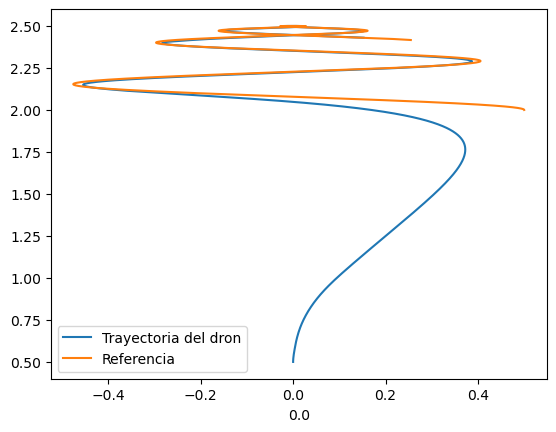

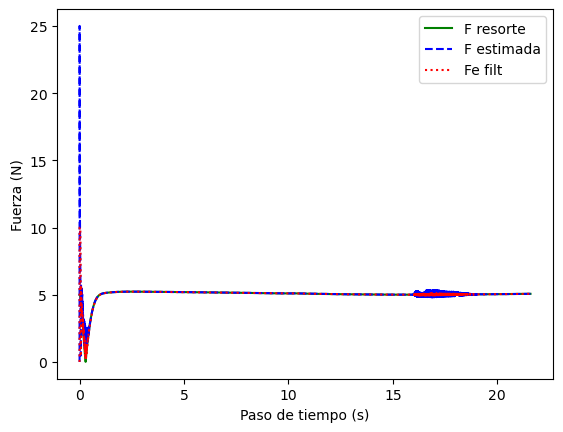

Fuerza estimada (filtrada) - media: 5.024148424809808 N


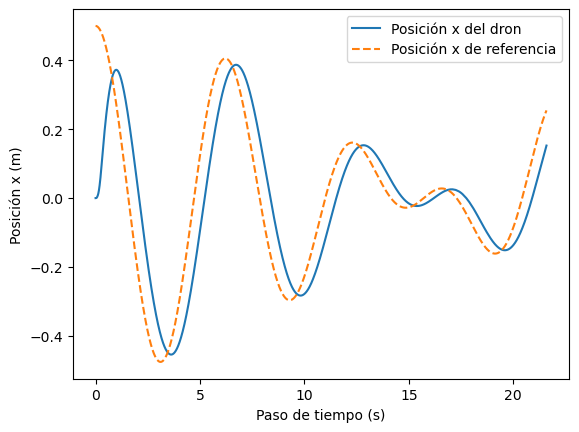

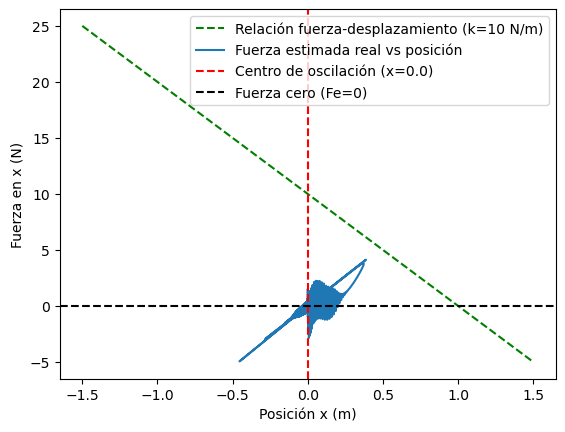

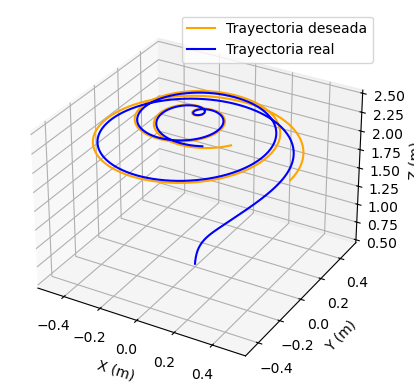

In [10]:
import numpy as np
import mujoco
from mujoco import viewer
import time
import matplotlib.pyplot as plt
from low_level_controller.mellinguer import MellinguerController
from low_level_controller.indi import INDIController
from helper import ForceArrow, PointMarker, quat_to_rotmat
from plot import plot_force_vs_time, plot_trajectory, plot_traj_and_ref

from acceleration_estimator import AccelerationEstimator
from force_observer.force_observer import ForceObserver
from force_observer.force_filter import MovingAverageForgettingFactorFilter

from path_generator import PathGenerator



# --- XML con actuadores directos u1,u2,u3,u4 ---
XML_PATH = "system/drone_spring_sphere_obs_u1234.xml"  # <-- pon aquí tu nuevo XML

model = mujoco.MjModel.from_xml_path(XML_PATH)
data = mujoco.MjData(model)
dt = model.opt.timestep

arrowVF = ForceArrow(model, data, arrow_idx=1) # virtual force (mocap)
arrowEF = ForceArrow(model, data, arrow_idx=2) # estimated force (mocap)
markerT = PointMarker(model, data, marker_idx=1) # referencia deseada (mocap)

# Body del dron
drone_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "drone_3d")
if drone_id < 0:
    raise ValueError("No existe el body 'drone_3d' en el XML.")

# Masa total del dron
m = float(model.body_subtreemass[drone_id])

# Posición inicial para hover
mujoco.mj_forward(model, data)
p0 = data.xpos[drone_id].copy()

# Gains como lista: [Kp_pos, Kv_pos, KR_att, Komega_att]
gains = [
    np.array([5.0, 5.0, 10.0]),         # Kp posición (diag)
    np.array([3.0, 3.0, 6.0]),          # Kv velocidad (diag)
    np.array([8.0, 8.0, 2.0]),    # KR actitud (diag)
    np.array([0.2, 0.2, 0.1])         # Komega velocidad angular (diag)
]

controller = MellinguerController(mass=m, gravity=9.81, gains=gains)


# (Opcional) si quieres asignar por nombre para evitar depender del orden:
act_u1 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u1_thrust")
act_u2 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u2_tau_x")
act_u3 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u3_tau_y")
act_u4 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u4_tau_z")
if min(act_u1, act_u2, act_u3, act_u4) < 0:
    raise ValueError("No encontré actuadores u1_thrust/u2_tau_x/u3_tau_y/u4_tau_z. Revisa el XML.")


# Inicializar estimador de aceleración, observador de fuerza y filtro de fuerza
acceleration_estimator = AccelerationEstimator(dt)
force_observer = ForceObserver(drone_mass=m, gravity=9.81)
force_filter = MovingAverageForgettingFactorFilter(window_size=15, forgetting_factor=0.9)
path_generator = PathGenerator()

# guardar para debug/visualización
vector_r = []
vector_rT = []
vector_Fe = [] # para guardar la fuerza estimada real (sin filtrar)
vector_Fe_filt = [] # para guardar la fuerza estimada filtrada para comparar
vector_F_res = [] # para guardar la fuerza teorica real del resorte
# Fe inicial
Fe_filt = np.zeros(3)
Fe = np.zeros(3)

with viewer.launch_passive(model, data) as vis:
    t = 0.0

    while vis.is_running():
        # ---------------------------
        # (1) Leer estado en MuJoCo
        # ---------------------------
        r = data.xpos[drone_id].copy()
        q = data.xquat[drone_id].copy()
        R = quat_to_rotmat(q)

        # cvel = [wx, wy, wz, vx, vy, vz] (world-aligned)
        cvel = data.cvel[drone_id].copy()
        omega_world = cvel[0:3]
        vel_world = cvel[3:6]

        # aceleración estimada (derivada numérica)
        a = acceleration_estimator.estimate(vel_world, noise=False, noise_std=1.5)

        # Tu controlador típicamente usa omega en body
        omega_body = R.T @ omega_world

        # Calcular fuerza teórica del resorte en 3D
        # F = k*(x-x0)
        p0_res = np.array([0.0, 0.0, 2.0]) # centro de oscilación
        r_rel = r - p0_res # posición relativa al centro del spring
        k = 10.0 # constante del resorte
        r_eq = r_rel * (1.0 / np.linalg.norm(r_rel)) # vector de equilibrio con módulo 1.5
        F_res = -k * (r_rel - r_eq) # fuerza del resorte (vectorial)
        # vector_F_res.append(F_res)



        # rT, vT, aT = path_generator.fixed_point([1.0, 0.0, 2.0])
        # rT, vT, aT = path_generator.do_circle_xz(t, radius=0.5, center=np.array([1.0, 0.0, 1.5]), omega=1.0)
        # rT, vT, aT = path_generator.do_circle_xy(t, radius=0.5, center=np.array([1.0, 0.0, 1.5]), omega=1.0)
        # rT, vT, aT = path_generator.do_circle_xy(t, radius=1.0, center=np.array([0.0, 0.0, 2.0]), omega=1.0)
        # rT, vT, aT = path_generator.do_sine_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.4, frequency=1.0)
        # rT, vT, aT = path_generator.do_square_xz(t, center=np.array([1.0, 0.0, 2.0]), side_length=0.5, omega=1.0)
        # rT, vT, aT = path_generator.do_chirp_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.4, f0=0.5, f1=2.0, T=10.0) # chirp para probar respuesta a frecuencias variables
        # rT, vT, aT = path_generator.do_square_signal_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.4, frequency=0.2)
        rT, vT, aT = path_generator.do_spherical_spiral(t, center=np.array([0.0, 0.0, 2.0]), radius=0.5, omega=1.0, vertical_speed=0.1)
        # rT, vT, aT = path_generator.do_fill_spherical_spiral(t, center=np.array([0.0, 0.0, 2.0]), radius=2.0, omega=0.5*np.sqrt(2), vertical_speed=0.5*(2)**(1/4))

        yaw_d = 0.0
        
        # vT = 0 # vuelve el seguimiento más lento
        # aT = 0


        # guardar para debug/visualización
        vector_r.append(r)
        vector_rT.append(rT)
        vector_Fe.append(Fe) # guardar la fuerza estimada real (sin filtrar)
        vector_Fe_filt.append(Fe_filt) # guardar la fuerza estimada filtrada para comparar
        vector_F_res.append(F_res) # guardar la fuerza teorica real del resorte
        # ---------------------------
        # (3) Control Mellinger -> u = [u1,u2,u3,u4]
        # ---------------------------

        u, Fv, _ = controller.step(rT, vT, aT, r, vel_world, a, R, omega_body, yaw_d, f_ext=Fe_filt)

        Fe = force_observer.observe(u1_sclr=u[0], drone_acceleration=a, R=R)
        Fe_filt = force_filter.filter(Fe, limit=True, max_force=10.0) # limitar fuerza filtrada para evitar valores extremos que rompan la simulación

        # ---------------------------
        # (4) Aplicar controles directo a actuadores
        # ---------------------------
        data.ctrl[act_u1] = u[0]
        data.ctrl[act_u2] = u[1]
        data.ctrl[act_u3] = u[2]
        data.ctrl[act_u4] = u[3]

        # ---------------------------
        # (5) Actualizar flechas de fuerza / estimar fuerza real / actualizar marker de referencia
        # ---------------------------

        if arrowVF is not None:
            arrowVF.update_force_arrow_mocap(p0_world=r, F_world=Fv, scale=0.03, max_len=0.8, radius=0.01)

        if arrowEF is not None:
            arrowEF.update_force_arrow_mocap(p0_world=r, F_world=Fe, scale=0.03, max_len=0.8, radius=0.01)


        if markerT is not None:
            markerT.update_point(p_world=rT, radius=0.01)

        # ---------------------------
        # (6) Paso de simulación
        # ---------------------------
        start = time.time()

        mujoco.mj_step(model, data)
        vis.sync()
        t += dt

        alpha = 0  # factor de ajuste para sincronización (puedes experimentar con valores <1.0 si el código de control es muy pesado)

        # sincronizar en tiempo real
        elapsed = time.time() - start
        sleep_time = (dt - elapsed)*alpha
        if sleep_time > 0:
            time.sleep(sleep_time)


# # visualización de trayectoria (opcional)
vector_r = np.array(vector_r)
vector_rT = np.array(vector_rT)
vector_Fe = np.array(vector_Fe)
vector_Fe_filt = np.array(vector_Fe_filt)
vector_F_res = np.array(vector_F_res)
# plot_trajectory(vector_r[:,0], vector_r[:,2], p0[0])
plot_traj_and_ref(vector_r[:,0], vector_r[:,2], vector_rT[:,0], vector_rT[:,2], p0[0])


import numpy as np

axt = np.linspace(0, len(vector_Fe)*dt, len(vector_Fe))

plot_force_vs_time(
    axt,
    np.linalg.norm(vector_F_res, axis=1), 'F resorte', '-', 'green',
    np.linalg.norm(vector_Fe, axis=1), 'F estimada', '--', 'blue',
    np.linalg.norm(vector_Fe_filt, axis=1), 'Fe filt', ':', 'red'
    

)

print("Fuerza estimada (filtrada) - media:", np.mean(np.linalg.norm(vector_Fe_filt, axis=1)), "N")

# Visualizacion de posicion x con respecto al tiempo
plt.figure()
plt.plot(axt, vector_r[:,0], label='Posición x del dron')
plt.plot(axt, vector_rT[:,0], label='Posición x de referencia', linestyle='--')
plt.xlabel('Paso de tiempo (s)')
plt.ylabel('Posición x (m)')
plt.legend()
plt.show()


# visualización de fuerza estimada real vs posición
plt.figure()
# trazar recta y=-k*(x-1.0) para visualizar relación fuerza-desplazamiento (con k=10 N/m)
k = 10.0
x_vals = np.linspace(-1.5, 1.5, 100)
y_vals = -k * (x_vals - 1.0)
plt.plot(x_vals, y_vals, 'g--', label='Relación fuerza-desplazamiento (k=10 N/m)')
# trazar fuerza estimada real vs posición x
plt.plot(vector_r[:,0], vector_Fe[:,0], label='Fuerza estimada real vs posición')
# trazar linea vertical en x = 0.0 (centro de oscilación)
plt.axvline(x=0.0, color='r', linestyle='--', label='Centro de oscilación (x=0.0)')
# trazar linea horizontal en Fe=0
plt.axhline(y=0.0, color='k', linestyle='--', label='Fuerza cero (Fe=0)')

plt.xlabel('Posición x (m)')
plt.ylabel('Fuerza en x (N)')
plt.legend()
plt.show()



# plot 3d de la trayectoria deseada
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(vector_rT[:,0], vector_rT[:,1], vector_rT[:,2], label='Trayectoria deseada', color='orange')
ax.plot(vector_r[:,0], vector_r[:,1], vector_r[:,2], label='Trayectoria real', color='blue')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.legend()
plt.show()


# LS and RLS Test

In [ ]:
import numpy as np

class VectorRLS:
    def __init__(self, n_features, n_outputs, lambda_=0.99, P0_scale=1000.0):
        self.n = n_features
        self.m = n_outputs
        self.lambda_ = lambda_

        # W: (n_features x n_outputs)
        self.W = np.zeros((n_features, n_outputs))

        # P: (n_features x n_features)
        self.P = P0_scale * np.eye(n_features)

    def predict(self, phi):
        phi = phi.reshape(-1, 1)  # (n x 1)
        return (self.W.T @ phi).flatten()  # (m,)

    def update(self, phi, F_real):
        phi = phi.reshape(-1, 1)        # (n x 1)
        F_real = F_real.reshape(-1, 1)  # (m x 1)

        # Predicción
        F_hat = self.W.T @ phi          # (m x 1)

        # Error vectorial
        error = F_real - F_hat          # (m x 1)

        # Ganancia
        denom = self.lambda_ + phi.T @ self.P @ phi
        K = (self.P @ phi) / denom      # (n x 1)

        # Update de W (nota: outer product)
        self.W = self.W + K @ error.T   # (n x m)

        # Update de P
        self.P = (1 / self.lambda_) * (
            self.P - K @ phi.T @ self.P
        )

        return F_hat.flatten(), error.flatten()
    


# Crear modelo
rls = VectorRLS(n_features=4, n_outputs=3, lambda_=0.99)

dt = 0.01

for t in range(1000):
    # Posición (ejemplo)
    x = np.sin(t * dt)
    y = np.cos(t * dt)
    z = 0.5 * np.sin(2 * t * dt)

    # Features
    phi = np.array([x, y, z, 1.0])

    # Campo real (desconocido)
    Fx = 2*x + 0.5*y
    Fy = -y + 0.3*z
    Fz = x - z

    F_real = np.array([Fx, Fy, Fz])

    # Update
    F_hat, error = rls.update(phi, F_real)

    # if t % 100 == 0:
    #     print(f"t={t}")
    #     print("F_hat:", F_hat)
    #     print("Error:", error)
    #     print()


import numpy as np
import matplotlib.pyplot as plt

def plot_vector_field_3d(model, grid_lim=0.5, n_points=6):
    # Crear grilla
    x = np.linspace(-grid_lim, grid_lim, n_points)
    y = np.linspace(-grid_lim, grid_lim, n_points)
    z = np.linspace(-grid_lim, grid_lim, n_points)

    X, Y, Z = np.meshgrid(x, y, z)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    W = np.zeros_like(Z)
    magnitude = np.zeros_like(X)

    # Evaluar el modelo en cada punto
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            for k in range(X.shape[2]):
                phi = np.array([X[i,j,k], Y[i,j,k], Z[i,j,k], 1.0])
                F = model.predict(phi)

                U[i,j,k] = F[0]
                V[i,j,k] = F[1]
                W[i,j,k] = F[2]

                magnitude[i,j,k] = np.linalg.norm(F)

    # Normalizar colores
    mag_norm = magnitude / (np.max(magnitude) + 1e-6)

    # Plot
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    ax.quiver(
        X, Y, Z,
        U, V, W,
        length=0.2,
        normalize=True,
        cmap='viridis',
        colors=plt.cm.viridis(mag_norm.flatten())
    )

    ax.set_title("Campo de fuerzas estimado")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    plt.show()

plot_vector_field_3d(rls)

Matriz A ajustada:
 [[-6.94297245  0.          2.75882554]
 [ 0.          0.          0.        ]
 [ 3.40298341  0.         -1.50505391]]


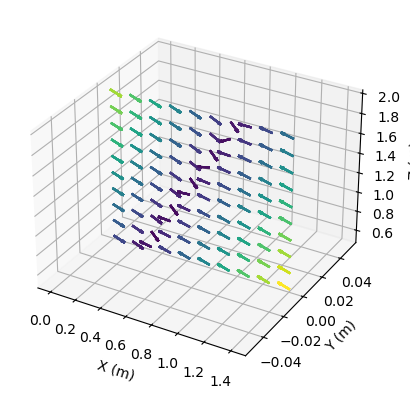

In [ ]:

# La fuerza del resorte F varía con respecto al espacio r.
# 




























# # # Fe_k = A*r_k
# # # tengo una serie de datos de posición R y fuerza estimada Fe, quiero ajustar una matriz A tal que Fe ≈ A*R
# # # vector_Fe y vector_r son mis datos de fuerza estimada y posición, respectivamente. Quiero encontrar una matriz A tal que Fe ≈ A*R. Esto es un problema de regresión lineal multivariable, donde R es la variable independiente (entrada) y Fe es la variable dependiente (salida). Puedo usar métodos como mínimos cuadrados para encontrar la mejor matriz A que ajuste los datos.
# # # Probamos primero LS con formula cerrada sin regularización:
# # R = vector_r # matriz de posiciones (Nx3)
# # Fe = vector_Fe # matriz de fuerzas estimadas (Nx3)

# # # Calculamos la matriz A usando la formula de mínimos cuadrados:
# # A = np.linalg.pinv(R) @ Fe
# # print("Matriz A ajustada:\n", A)

# # # Ahora podemos usar esta matriz A para predecir la fuerza a partir de la posición y comparar con la fuerza estimada real:
# # Fe_pred = R @ A
# # # print("Fuerza predicha:\n", Fe_pred)


# # # Hacer un plot en 3d con un campo vectorial de la fuerza predicha por el modelo ajustado (Fe_pred) en función de la posición (R):
# # # hacer samples para no llenar todo el espacio, tambien escalar los vectores para que se vean bien en el plot, el tamaño de los vectores deben ser iguales, solo cambio el color segun la magnitud de la fuerza
# # # sample_indices = np.random.choice(len(R), size=100, replace=False) # tomar una muestra aleatoria de 200 puntos para el plot
# # # tomar muestra de un grido regular en el espacio para visualizar mejor la relación entre posición y fuerza
# # x_samples = np.linspace(np.min(R[:,0]), np.max(R[:,0]), 10)
# # y_samples = np.linspace(np.min(R[:,1]), np.max(R[:,1]), 10)
# # z_samples = np.linspace(np.min(R[:,2]), np.max(R[:,2]), 10)
# # X, Y, Z = np.meshgrid(x_samples, y_samples, z_samples)
# # R_sample = np.column_stack((X.ravel(), Y.ravel(), Z.ravel()))
# # Fe_pred_sample = R_sample @ A
# # Fe_magnitude = np.linalg.norm(Fe_pred_sample, axis=1)
# # Fe_magnitude_normalized = Fe_magnitude / np.max(Fe_magnitude) # normalizar magnitudes para el color
# # colors = plt.cm.viridis(Fe_magnitude_normalized) # usar un mapa de colores para representar la magnitud de la fuerza
# # fig = plt.figure()
# # ax = fig.add_subplot(111, projection='3d')
# # ax.quiver(R_sample[:,0], R_sample[:,1], R_sample[:,2], Fe_pred_sample[:,0], Fe_pred_sample[:,1], Fe_pred_sample[:,2], length=0.1, normalize=True, color=colors)
# # ax.set_xlabel('X (m)')
# # ax.set_ylabel('Y (m)')
# # ax.set_zlabel('Z (m)')
# # plt.show()


# Spring Drone RLS (Recursive Least Squares)
Implement a force estimator for the object force as an external constant force.

In [ ]:
import numpy as np
import mujoco
from mujoco import viewer
import time
import matplotlib.pyplot as plt
from low_level_controller.mellinguer import MellinguerController
from low_level_controller.indi import INDIController
from helper import ForceArrow, PointMarker, quat_to_rotmat
from plot import plot_force_vs_time, plot_trajectory, plot_traj_and_ref

from acceleration_estimator import AccelerationEstimator
from force_observer.force_observer import ForceObserver
from force_observer.force_filter import MovingAverageForgettingFactorFilter

from path_generator import PathGenerator



# --- XML con actuadores directos u1,u2,u3,u4 ---
XML_PATH = "system/drone_spring_sphere_obs_u1234.xml"  # <-- pon aquí tu nuevo XML

model = mujoco.MjModel.from_xml_path(XML_PATH)
data = mujoco.MjData(model)
dt = model.opt.timestep

arrowVF = ForceArrow(model, data, arrow_idx=1) # virtual force (mocap)
arrowEF = ForceArrow(model, data, arrow_idx=2) # estimated force (mocap)
markerT = PointMarker(model, data, marker_idx=1) # referencia deseada (mocap)

# Body del dron
drone_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "drone_3d")
if drone_id < 0:
    raise ValueError("No existe el body 'drone_3d' en el XML.")

# Masa total del dron
m = float(model.body_subtreemass[drone_id])

# Posición inicial para hover
mujoco.mj_forward(model, data)
p0 = data.xpos[drone_id].copy()

# Gains como lista: [Kp_pos, Kv_pos, KR_att, Komega_att]
gains = [
    np.array([5.0, 5.0, 10.0]),         # Kp posición (diag)
    np.array([3.0, 3.0, 6.0]),          # Kv velocidad (diag)
    np.array([8.0, 8.0, 2.0]),    # KR actitud (diag)
    np.array([0.2, 0.2, 0.1])         # Komega velocidad angular (diag)
]

controller = MellinguerController(mass=m, gravity=9.81, gains=gains)


# (Opcional) si quieres asignar por nombre para evitar depender del orden:
act_u1 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u1_thrust")
act_u2 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u2_tau_x")
act_u3 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u3_tau_y")
act_u4 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u4_tau_z")
if min(act_u1, act_u2, act_u3, act_u4) < 0:
    raise ValueError("No encontré actuadores u1_thrust/u2_tau_x/u3_tau_y/u4_tau_z. Revisa el XML.")


# Inicializar estimador de aceleración, observador de fuerza y filtro de fuerza
acceleration_estimator = AccelerationEstimator(dt)
force_observer = ForceObserver(drone_mass=m, gravity=9.81)
force_filter = MovingAverageForgettingFactorFilter(window_size=15, forgetting_factor=0.9)
path_generator = PathGenerator()

# guardar para debug/visualización
vector_r = []
vector_rT = []
vector_Fe = [] # para guardar la fuerza estimada real (sin filtrar)
vector_Fe_filt = [] # para guardar la fuerza estimada filtrada para comparar
vector_F_res = [] # para guardar la fuerza teorica real del resorte
# Fe inicial
Fe_filt = np.zeros(3)
Fe = np.zeros(3)

with viewer.launch_passive(model, data) as vis:
    t = 0.0

    while vis.is_running():
        # ---------------------------
        # (1) Leer estado en MuJoCo
        # ---------------------------
        r = data.xpos[drone_id].copy()
        q = data.xquat[drone_id].copy()
        R = quat_to_rotmat(q)

        # cvel = [wx, wy, wz, vx, vy, vz] (world-aligned)
        cvel = data.cvel[drone_id].copy()
        omega_world = cvel[0:3]
        vel_world = cvel[3:6]

        # aceleración estimada (derivada numérica)
        a = acceleration_estimator.estimate(vel_world, noise=False, noise_std=1.5)

        # Tu controlador típicamente usa omega en body
        omega_body = R.T @ omega_world

        # Calcular fuerza teórica del resorte en 3D
        # F = k*(x-x0)
        p0_res = np.array([0.0, 0.0, 2.0]) # centro de oscilación
        r_rel = r - p0_res # posición relativa al centro del spring
        k = 10.0 # constante del resorte
        r_eq = r_rel * (1.0 / np.linalg.norm(r_rel)) # vector de equilibrio con módulo 1.5
        F_res = -k * (r_rel - r_eq) # fuerza del resorte (vectorial)
        # vector_F_res.append(F_res)



        # rT, vT, aT = path_generator.fixed_point([1.0, 0.0, 2.0])
        # rT, vT, aT = path_generator.do_circle_xz(t, radius=0.5, center=np.array([1.0, 0.0, 1.5]), omega=1.0)
        # rT, vT, aT = path_generator.do_circle_xy(t, radius=0.5, center=np.array([1.0, 0.0, 1.5]), omega=1.0)
        # rT, vT, aT = path_generator.do_circle_xy(t, radius=1.0, center=np.array([0.0, 0.0, 2.0]), omega=1.0)
        rT, vT, aT = path_generator.do_sine_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.4, frequency=1.0)
        # rT, vT, aT = path_generator.do_square_xz(t, center=np.array([1.0, 0.0, 2.0]), side_length=0.5, omega=1.0)
        # rT, vT, aT = path_generator.do_chirp_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.4, f0=0.5, f1=2.0, T=10.0) # chirp para probar respuesta a frecuencias variables
        # rT, vT, aT = path_generator.do_square_signal_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.4, frequency=0.2)
        # rT, vT, aT = path_generator.do_spherical_spiral(t, center=np.array([0.0, 0.0, 2.0]), radius=0.5, omega=1.0, vertical_speed=0.1)
        # rT, vT, aT = path_generator.do_fill_spherical_spiral(t, center=np.array([0.0, 0.0, 2.0]), radius=2.0, omega=0.5*np.sqrt(2), vertical_speed=0.5*(2)**(1/4))

        yaw_d = 0.0
        
        # vT = 0 # vuelve el seguimiento más lento
        # aT = 0


        # guardar para debug/visualización
        vector_r.append(r)
        vector_rT.append(rT)
        vector_Fe.append(Fe) # guardar la fuerza estimada real (sin filtrar)
        vector_Fe_filt.append(Fe_filt) # guardar la fuerza estimada filtrada para comparar
        vector_F_res.append(F_res) # guardar la fuerza teorica real del resorte
        # ---------------------------
        # (3) Control Mellinger -> u = [u1,u2,u3,u4]
        # ---------------------------

        u, Fv, _ = controller.step(rT, vT, aT, r, vel_world, a, R, omega_body, yaw_d, f_ext=Fe_filt)

        Fe = force_observer.observe(u1_sclr=u[0], drone_acceleration=a, R=R)
        Fe_filt = force_filter.filter(Fe, limit=True, max_force=10.0) # limitar fuerza filtrada para evitar valores extremos que rompan la simulación

        # ---------------------------
        # (4) Aplicar controles directo a actuadores
        # ---------------------------
        data.ctrl[act_u1] = u[0]
        data.ctrl[act_u2] = u[1]
        data.ctrl[act_u3] = u[2]
        data.ctrl[act_u4] = u[3]

        # ---------------------------
        # (5) Actualizar flechas de fuerza / estimar fuerza real / actualizar marker de referencia
        # ---------------------------

        if arrowVF is not None:
            arrowVF.update_force_arrow_mocap(p0_world=r, F_world=Fv, scale=0.03, max_len=0.8, radius=0.01)

        if arrowEF is not None:
            arrowEF.update_force_arrow_mocap(p0_world=r, F_world=Fe, scale=0.03, max_len=0.8, radius=0.01)


        if markerT is not None:
            markerT.update_point(p_world=rT, radius=0.01)

        # ---------------------------
        # (6) Paso de simulación
        # ---------------------------
        start = time.time()

        mujoco.mj_step(model, data)
        vis.sync()
        t += dt

        alpha = 0  # factor de ajuste para sincronización (puedes experimentar con valores <1.0 si el código de control es muy pesado)

        # sincronizar en tiempo real
        elapsed = time.time() - start
        sleep_time = (dt - elapsed)*alpha
        if sleep_time > 0:
            time.sleep(sleep_time)


# # visualización de trayectoria (opcional)
vector_r = np.array(vector_r)
vector_rT = np.array(vector_rT)
vector_Fe = np.array(vector_Fe)
vector_Fe_filt = np.array(vector_Fe_filt)
vector_F_res = np.array(vector_F_res)
# plot_trajectory(vector_r[:,0], vector_r[:,2], p0[0])
plot_traj_and_ref(vector_r[:,0], vector_r[:,2], vector_rT[:,0], vector_rT[:,2], p0[0])


import numpy as np

axt = np.linspace(0, len(vector_Fe)*dt, len(vector_Fe))

plot_force_vs_time(
    axt,
    np.linalg.norm(vector_F_res, axis=1), 'F resorte', '-', 'green',
    np.linalg.norm(vector_Fe, axis=1), 'F estimada', '--', 'blue',
    np.linalg.norm(vector_Fe_filt, axis=1), 'Fe filt', ':', 'red'
    

)

print("Fuerza estimada (filtrada) - media:", np.mean(np.linalg.norm(vector_Fe_filt, axis=1)), "N")

# Visualizacion de posicion x con respecto al tiempo
plt.figure()
plt.plot(axt, vector_r[:,0], label='Posición x del dron')
plt.plot(axt, vector_rT[:,0], label='Posición x de referencia', linestyle='--')
plt.xlabel('Paso de tiempo (s)')
plt.ylabel('Posición x (m)')
plt.legend()
plt.show()


# visualización de fuerza estimada real vs posición
plt.figure()
# trazar recta y=-k*(x-1.0) para visualizar relación fuerza-desplazamiento (con k=10 N/m)
k = 10.0
x_vals = np.linspace(-1.5, 1.5, 100)
y_vals = -k * (x_vals - 1.0)
plt.plot(x_vals, y_vals, 'g--', label='Relación fuerza-desplazamiento (k=10 N/m)')
# trazar fuerza estimada real vs posición x
plt.plot(vector_r[:,0], vector_Fe[:,0], label='Fuerza estimada real vs posición')
# trazar linea vertical en x = 0.0 (centro de oscilación)
plt.axvline(x=0.0, color='r', linestyle='--', label='Centro de oscilación (x=0.0)')
# trazar linea horizontal en Fe=0
plt.axhline(y=0.0, color='k', linestyle='--', label='Fuerza cero (Fe=0)')

plt.xlabel('Posición x (m)')
plt.ylabel('Fuerza en x (N)')
plt.legend()
plt.show()



# plot 3d de la trayectoria deseada
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(vector_rT[:,0], vector_rT[:,1], vector_rT[:,2], label='Trayectoria deseada', color='orange')
ax.plot(vector_r[:,0], vector_r[:,1], vector_r[:,2], label='Trayectoria real', color='blue')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.legend()
plt.show()